## **Introduction**
Build a model to predict phone prices from specs (RAM, battery, camera, etc.). 2000 phones, 4 price ranges.

**Goal**: Help companies price smarter & customers find value.

## **Importing Libraries**

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## **Ignoring warning**

In [34]:
import warnings
warnings.filterwarnings('ignore')

## **To have better visualization we set style**

In [35]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## **Data loading**

In [36]:
df = pd.read_csv('/content/drive/MyDrive/Mobile_Price_Project/data/train.csv')

### **To understand our data before modeling we did our dataset Load and explored**

Basic information of dataset

In [37]:
print("="*50)
print("DATASET OVERVIEW")
print("="*50)

print(f"Dataset shape: {df.shape}")
print(f"Number of features: {df.shape[1]-1}")
print(f"Target classes: {df['price_range'].unique()}")
print(f"\nTarget distribution:")
print(df['price_range'].value_counts().sort_index().to_string())

DATASET OVERVIEW
Dataset shape: (2000, 21)
Number of features: 20
Target classes: [1 2 3 0]

Target distribution:
price_range
0    500
1    500
2    500
3    500


Looking first 5 rows of data and displying data types and info

In [38]:
print("First 5 rows of data:")
display(df.head())

print("\nData types and memory usage:")
df.info()

First 5 rows of data:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1



Data types and memory usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 no

looking statistical summary and checking missing values

In [39]:
print("Statistical summary:")
display(df.describe())

print("\n Missing values check:")
print(df.isnull().sum())

Statistical summary:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000



 Missing values check:
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


## **To find patterns and relationships we have to do Exploratory Data Analysis**

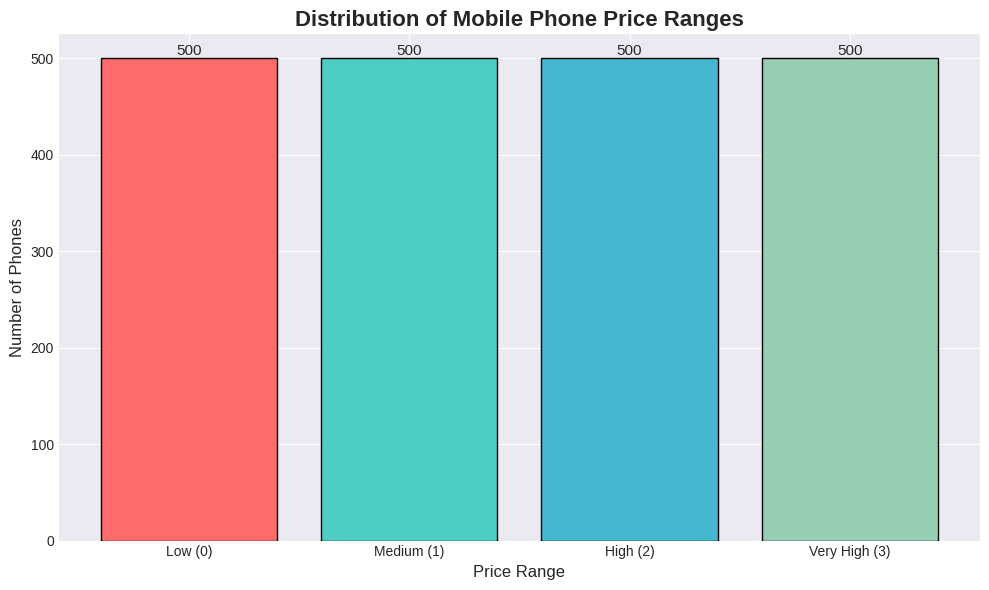

In [40]:
# Target variable distribution

plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
counts = df['price_range'].value_counts().sort_index()
bars = plt.bar(['Low (0)', 'Medium (1)', 'High (2)', 'Very High (3)'],
                counts, color=colors, edgecolor='black')
plt.title('Distribution of Mobile Phone Price Ranges', fontsize=16, fontweight='bold')
plt.xlabel('Price Range', fontsize=12)
plt.ylabel('Number of Phones', fontsize=12)

# Added value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Mobile_Price_Project/figures/mobile_price_range.png')
plt.show()

🔗 Feature correlation with price range:

Top 10 features most correlated with price:


,Feature,Correlation
0,ram,0.917046
1,battery_power,0.200723
2,px_width,0.165818
3,px_height,0.148858
4,int_memory,0.044435
5,sc_w,0.038711
6,pc,0.033599
7,three_g,0.023611
8,sc_h,0.022986
9,fc,0.021998


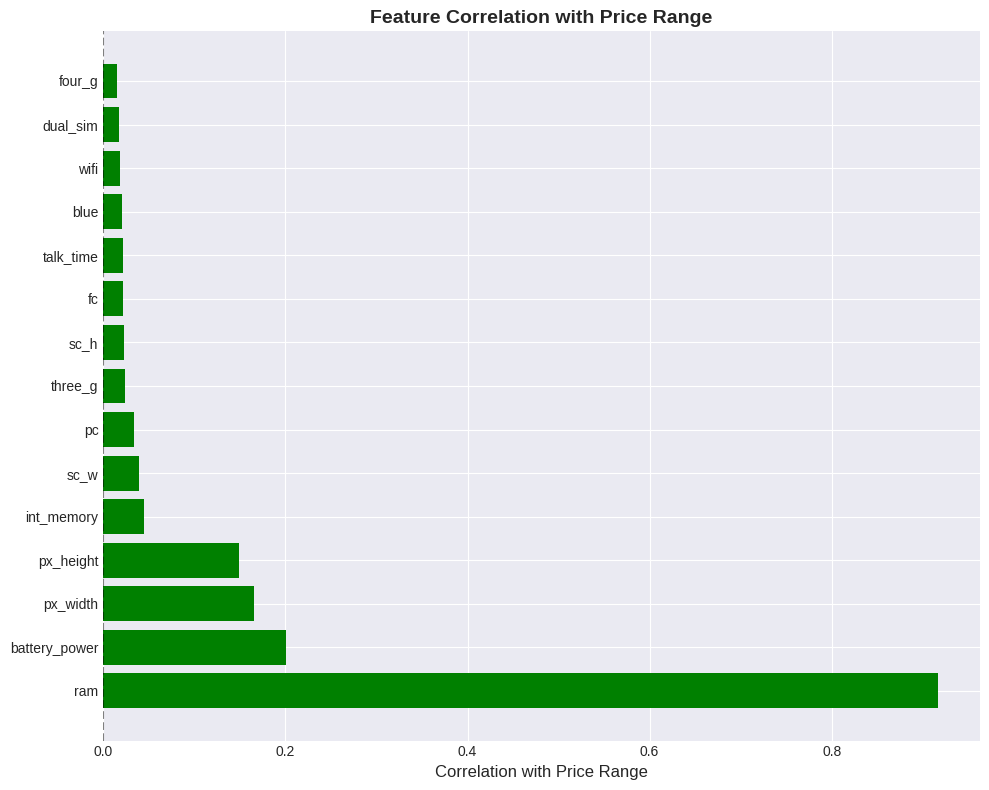

In [41]:
# 2. Correlation with target variable
print("🔗 Feature correlation with price range:")
correlations = df.corr()['price_range'].drop('price_range').sort_values(ascending=False)
correlations_df = pd.DataFrame(correlations).reset_index()
correlations_df.columns = ['Feature', 'Correlation']

# Display top features
print("\nTop 10 features most correlated with price:")
display(correlations_df.head(10))

# Visualization
plt.figure(figsize=(10, 8))
colors = ['green' if x > 0 else 'red' for x in correlations.values]
plt.barh(correlations.index[:15], correlations.values[:15], color=colors[:15])
plt.xlabel('Correlation with Price Range', fontsize=12)
plt.title('Feature Correlation with Price Range', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Mobile_Price_Project/figures/correlation_with_price_range.png')
plt.show()

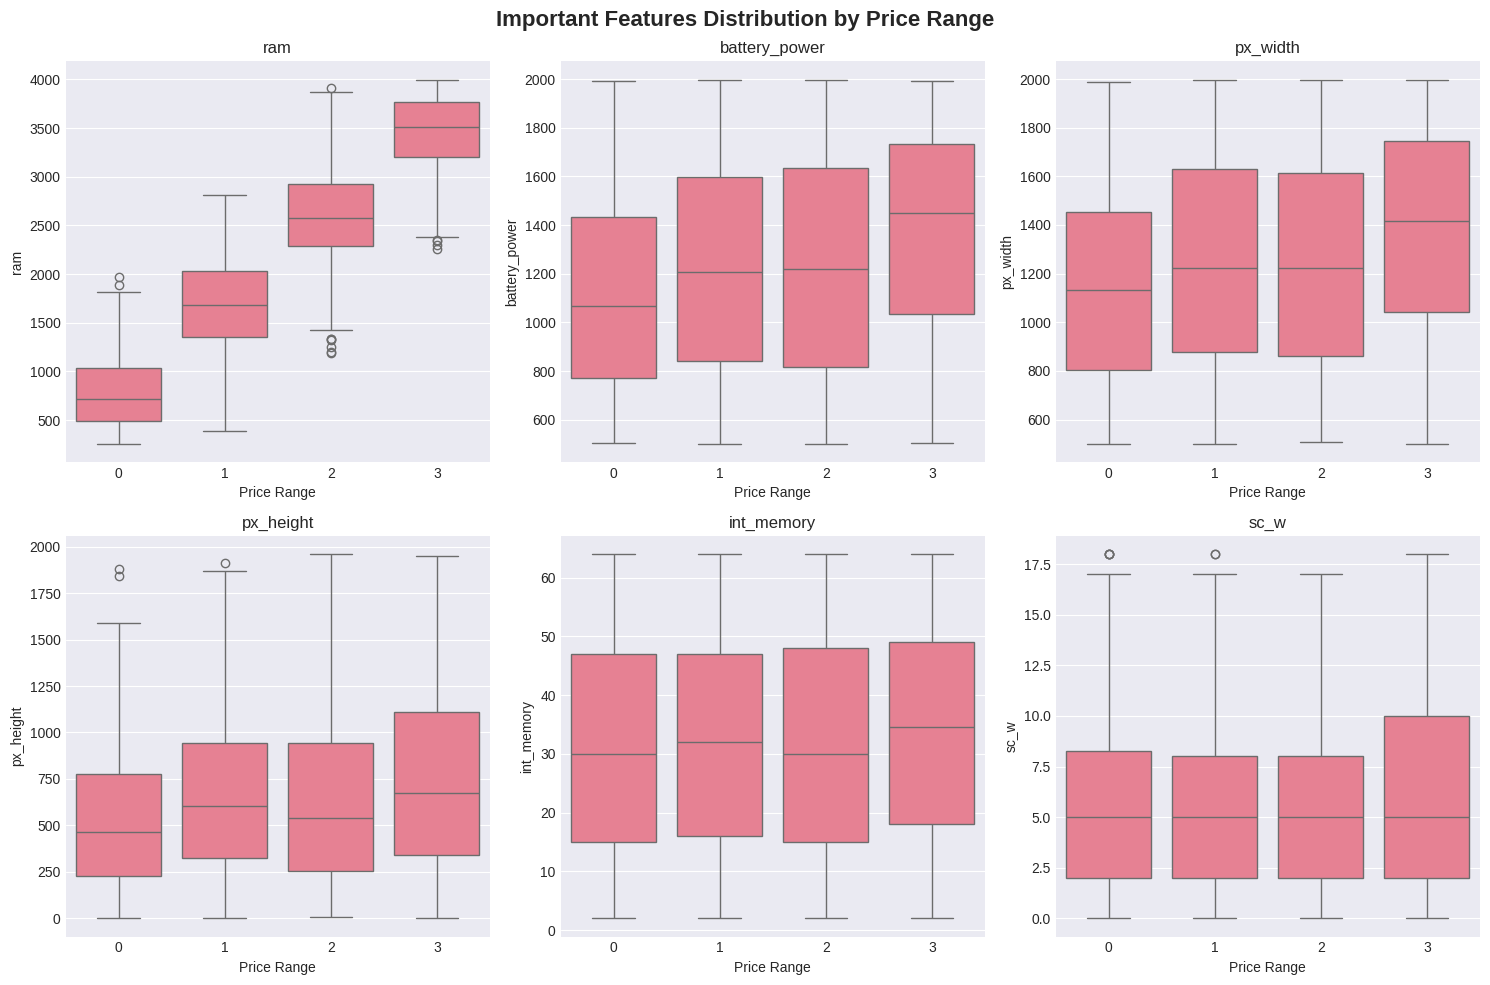

In [42]:
# 3. Distribution of important features by price range
important_features = correlations.index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Important Features Distribution by Price Range', fontsize=16, fontweight='bold')

for idx, feature in enumerate(important_features):
    row, col = idx // 3, idx % 3
    sns.boxplot(data=df, x='price_range', y=feature, ax=axes[row, col])
    axes[row, col].set_title(f'{feature}', fontsize=12)
    axes[row, col].set_xlabel('Price Range', fontsize=10)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Mobile_Price_Project/figures/features_importance_distribution.png')
plt.show()

Correlation heatmap

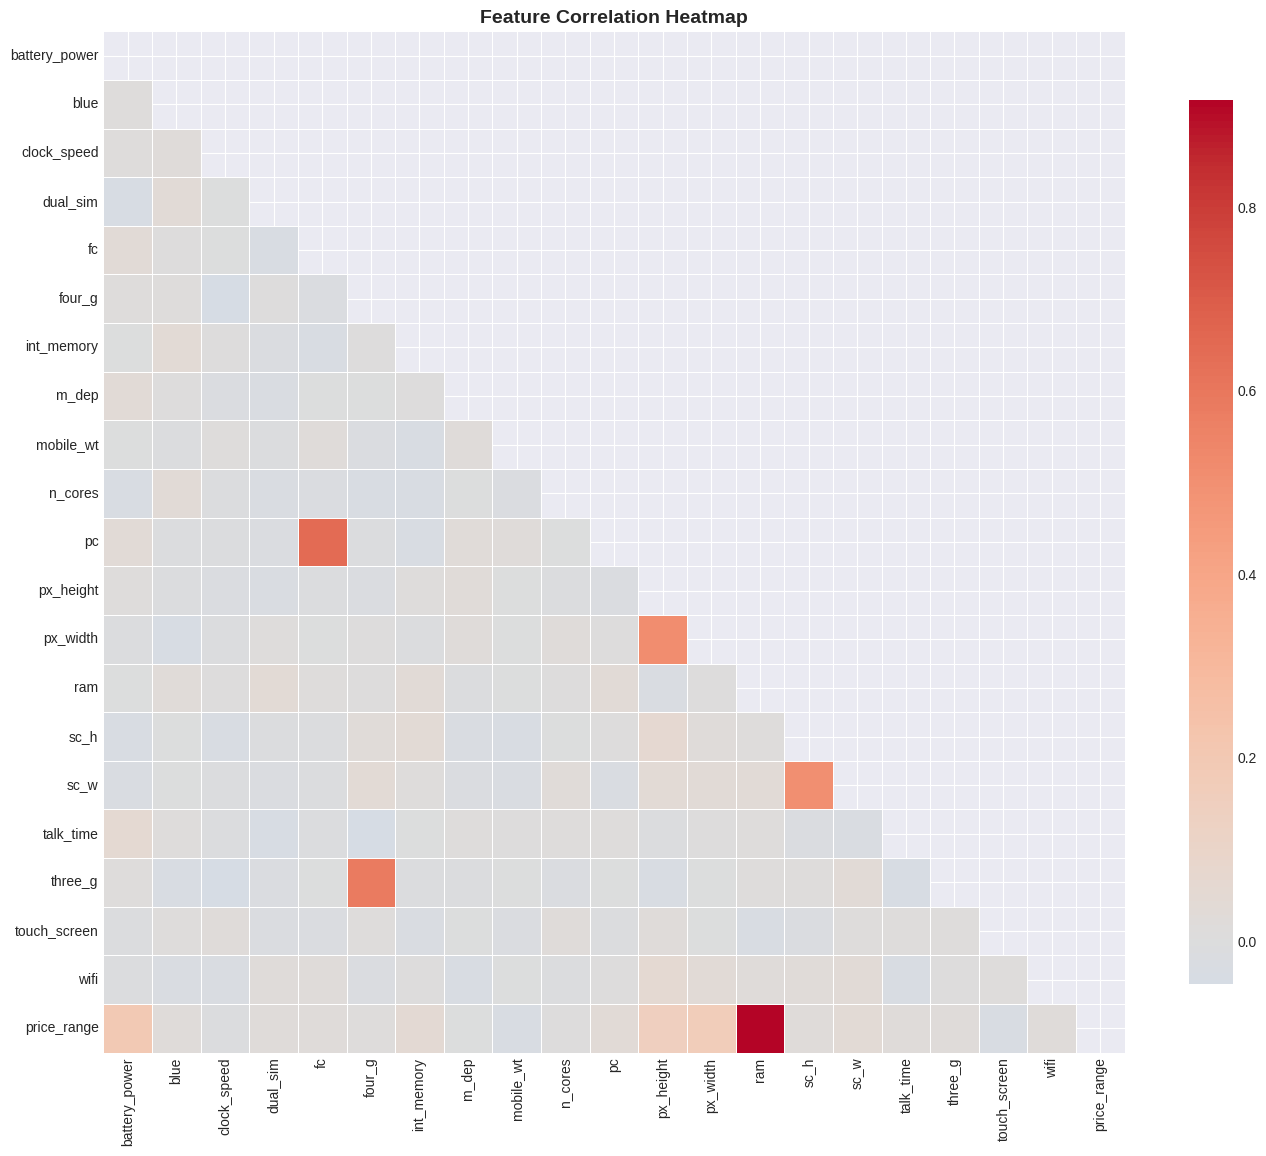

In [43]:
plt.figure(figsize=(14, 12))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot=False, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Mobile_Price_Project/figures/feature_correlation_heatmap.png')
plt.show()

## **Model Development**

In [44]:
# Prepare data for modeling
print("Preparing data for modeling")

# Separate features and target
X = df.drop('price_range', axis=1)
y = df['price_range']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!!!...")

Preparing data for modeling
Training set: 1600 samples
Test set: 400 samples
Features scaled successfully!!!...


Train and testing

In [45]:
# Define models to test
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Train and evaluate each model
results = {}

print("Training models...")
print("="*60)

for name, model in models.items():
    print(f"\n Training {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")

Training models...

 Training Logistic Regression...
Logistic Regression Accuracy: 0.9650

 Training K-Nearest Neighbors...
K-Nearest Neighbors Accuracy: 0.5000

 Training Support Vector Machine...
Support Vector Machine Accuracy: 0.8950

 Training Random Forest...
Random Forest Accuracy: 0.8800

 Training Gradient Boosting...
Gradient Boosting Accuracy: 0.9125


## **Model comparison and performance summary**

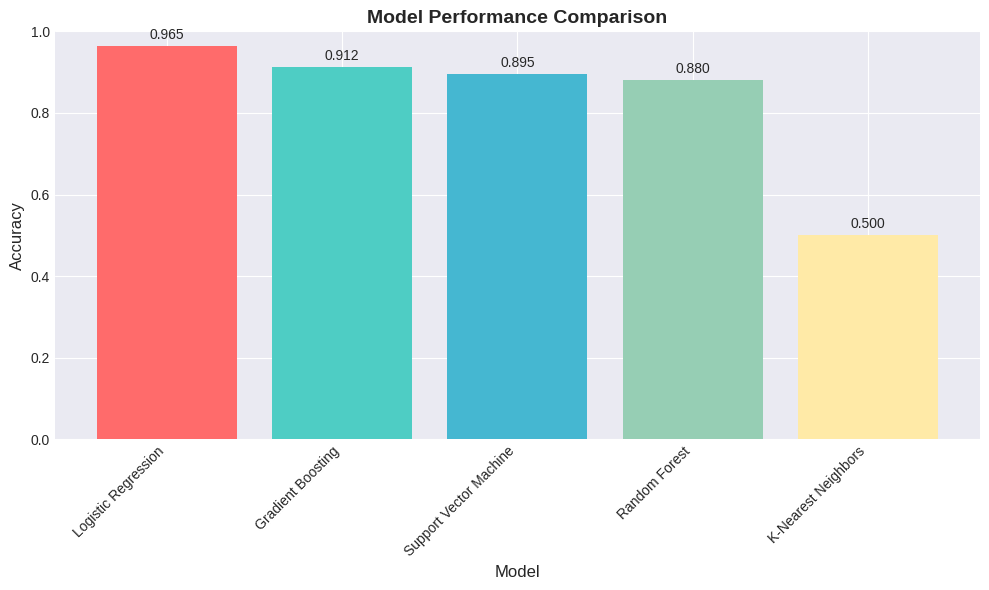


 Model Performance Summary:


,Model,Accuracy
0,Logistic Regression,0.9650
4,Gradient Boosting,0.9125
2,Support Vector Machine,0.8950
3,Random Forest,0.8800
1,K-Nearest Neighbors,0.5000


In [46]:
# Model comparison
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values('Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(results_df['Model'], results_df['Accuracy'],
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)

# Add accuracy labels
for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Mobile_Price_Project/figures/model_performance_comparison.png')
plt.show()

print("\n Model Performance Summary:")
display(results_df)

## **Hyperparameter Tuning**

In [47]:
from sklearn.model_selection import GridSearchCV

print("Starting Hyperparameter Tuning...")
print("Testing different combinations, please wait...")

# 1. Define the 'Menu' of settings we want to test
param_grid = {
    'n_estimators': [100, 200],      # Trying 100 trees vs 200 trees
    'max_depth': [10, 20, None],     # How deep the trees should go
    'min_samples_split': [2, 5],     # Minimum samples to split a branch
    'min_samples_leaf': [1, 2]       # Minimum samples at the end of a branch
}

# 2. Initialize the Grid Search
# cv=5 means it will test each combination 5 times using different parts of the data
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

# 3. Start the search (Fitting)
grid_search.fit(X_train_scaled, y_train)

# 4.Show the results
print("TUNING COMPLETED!")
print(f"Best Settings Found: {grid_search.best_params_}")
print(f"Best Internal Accuracy: {grid_search.best_score_ * 100:.2f}%")

# 5.Compare with our previous model
best_rf_model = grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test_scaled)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

print(f"\nFinal Tuned Model Test Accuracy: {tuned_accuracy * 100:.2f}%")

Starting Hyperparameter Tuning...
Testing different combinations, please wait...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
TUNING COMPLETED!
Best Settings Found: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best Internal Accuracy: 87.06%

Final Tuned Model Test Accuracy: 88.75%


Classification report for tuned model

In [48]:
# Classification report for tuned model
print("Classification Report for Tuned Random Forest:")
print("="*55)
print(classification_report(y_test, y_pred_tuned, target_names=['Low', 'Medium', 'High', 'Very High']))

Classification Report for Tuned Random Forest:
              precision    recall  f1-score   support

         Low       0.93      0.96      0.95       100
      Medium       0.84      0.82      0.83       100
        High       0.84      0.82      0.83       100
   Very High       0.94      0.95      0.95       100

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400



## **To understand what drives phone prices, it's time for doing Feature Importance Analysing**

Top 10 Most Important Features:


,Feature,Importance
13,ram,0.518508
0,battery_power,0.073349
12,px_width,0.058542
11,px_height,0.053038
8,mobile_wt,0.036317
6,int_memory,0.035716
16,talk_time,0.027883
10,pc,0.027199
2,clock_speed,0.025010
14,sc_h,0.024810


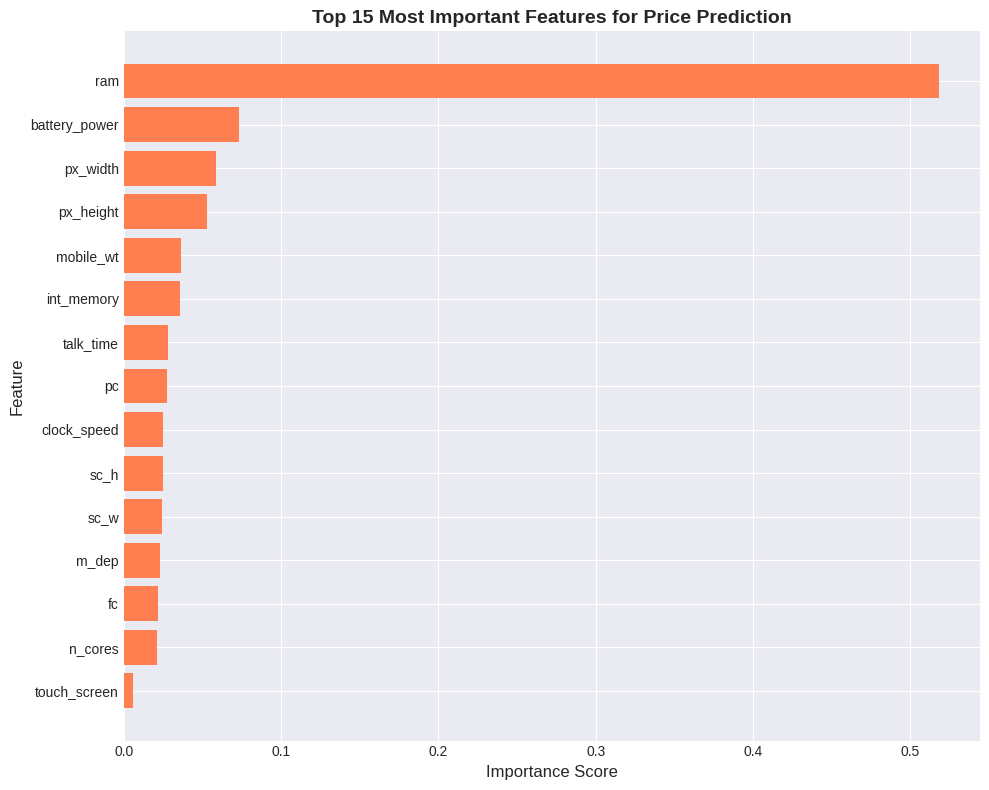

In [49]:
# Feature importance
best_rf = grid_search.best_estimator_
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 Most Important Features:")
display(feature_importance.head(10))

# Visualization
plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'].head(15),
         feature_importance['Importance'].head(15),
         color='coral')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 15 Most Important Features for Price Prediction',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Mobile_Price_Project/figures/top10_price_prediction_feature_.png')
plt.show()

## **To ensure our model is reliable we are going to do model evaluation**

# Confusion Matrix

<Figure size 800x600 with 0 Axes>

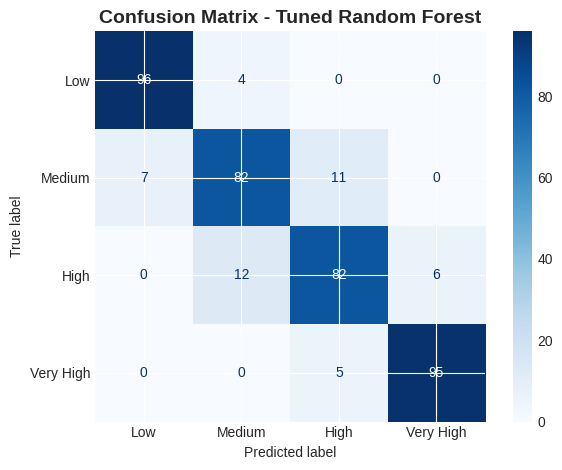

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Low', 'Medium', 'High', 'Very High'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Tuned Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Mobile_Price_Project/figures/confusion_matrix.png')
plt.show()

Cross-validation

In [51]:
cv_scores = cross_val_score(best_rf, X_train_scaled, y_train, cv=5)
print("5-Fold Cross-Validation Results:")
print(f"Individual scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation: {cv_scores.std():.4f}")
print(f"95% Confidence interval: [{cv_scores.mean() - 2*cv_scores.std():.4f}, "
      f"{cv_scores.mean() + 2*cv_scores.std():.4f}]")

5-Fold Cross-Validation Results:
Individual scores: [0.878125 0.865625 0.88125  0.8625   0.865625]
Mean CV accuracy: 0.8706
Standard deviation: 0.0076
95% Confidence interval: [0.8555, 0.8857]


### **Prediction making**

In [52]:
# Function to predict price range
def predict_price_range(features_dict, model, scaler, feature_names):
    """
    Predict price range for a mobile phone
    Parameters:
    features_dict: dictionary with feature names and values
    model: trained model
    scaler: fitted StandardScaler
    feature_names: list of feature names in correct order

    Returns:
    prediction: integer (0-3)
    price_label: string description
    """
    # Create feature array in correct order
    features = [features_dict[name] for name in feature_names]

    # Scale features
    features_scaled = scaler.transform([features])

    # Make prediction
    prediction = model.predict(features_scaled)[0]

    # Map prediction to label
    price_labels = {
        0: "Low Cost (Budget Phone)",
        1: "Medium Cost (Mid-range Phone)",
        2: "High Cost (Premium Phone)",
        3: "Very High Cost (Flagship Phone)"
    }

    return prediction, price_labels[prediction]

# Example: Predict for a new phone
print("Example Prediction")
print("="*55)

# Example phone specifications
new_phone = {
    'battery_power': 2000,
    'blue': 1,
    'clock_speed': 2.5,
    'dual_sim': 1,
    'fc': 8,
    'four_g': 1,
    'int_memory': 64,
    'm_dep': 0.5,
    'mobile_wt': 150,
    'n_cores': 8,
    'pc': 16,
    'px_height': 1080,
    'px_width': 1920,
    'ram': 4096,
    'sc_h': 12,
    'sc_w': 6,
    'talk_time': 15,
    'three_g': 1,
    'touch_screen': 1,
    'wifi': 1
}

# Get feature names in correct order
feature_names = X.columns.tolist()

# Make prediction
pred, label = predict_price_range(new_phone, best_rf, scaler, feature_names)

print(f" Phone Specifications:")
for key, value in new_phone.items():
  print(f" {key}: {value}")
print(f"\nPredicted Price Range: {label}")

Example Prediction
 Phone Specifications:
 battery_power: 2000
 blue: 1
 clock_speed: 2.5
 dual_sim: 1
 fc: 8
 four_g: 1
 int_memory: 64
 m_dep: 0.5
 mobile_wt: 150
 n_cores: 8
 pc: 16
 px_height: 1080
 px_width: 1920
 ram: 4096
 sc_h: 12
 sc_w: 6
 talk_time: 15
 three_g: 1
 touch_screen: 1
 wifi: 1

Predicted Price Range: Very High Cost (Flagship Phone)


## **Saving best model and scalar**

In [53]:
import joblib

joblib.dump(best_rf, '/content/drive/MyDrive/Mobile_Price_Project/models/best_model.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/Mobile_Price_Project/models/scaler.pkl')

['/content/drive/MyDrive/Mobile_Price_Project/models/scaler.pkl']

## **Results**

**Model	Accuracy**

Logistic Regression	96.5% ( King of this model)

Gradient Boosting	91.3%

SVM	89.5%

Random Forest	88.0%

KNN	50.0%

**Final Model**: Random Forest (Tuned) → 88.75%

##Top Features:

RAM → 52%

Battery → 7.3%

Screen → 5.9%

**Key Insight:**
RAM alone decides >50% of phone price!

**Bottom Line:**
Model predicts prices with 89% accuracy.
If you want to have a fair price, Check the RAM first.

In [54]:
print("\nProject Completed Successfully!")


Project Completed Successfully!
